# Step 2 - Neural Network

In this notebook I will build a neural network on the same dataset I used in Step 1.

I will use the same features and the same train/test split, then compare the results
with the three models I already trained.

## 2.1 - Prepare the Data (same as Step 1)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [2]:
# I load the same cleaned data and repeat the same preparation steps
# so this notebook runs on its own without depending on Step 1

df = pd.read_csv("data/cleaned/cars_cleaned.csv")

# Create the target label: 0 = cheap, 1 = expensive
median_price = df["price"].median()
df["price_label"] = (df["price"] > median_price).astype(int)

# Convert text columns to numbers
cat_cols = ["manufacturer", "fuel", "transmission", "condition"]
le = LabelEncoder()
for col in cat_cols:
    if col in df.columns:
        df[col] = le.fit_transform(df[col].astype(str))

# Select features
feature_cols = ["year", "odometer", "manufacturer", "fuel", "transmission", "condition"]
feature_cols = [c for c in feature_cols if c in df.columns]

X = df[feature_cols]
y = df["price_label"]

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale the features
# Neural networks are very sensitive to feature scale,
# so scaling is important here
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Data ready.")
print("Training set:", X_train_scaled.shape)
print("Test set:", X_test_scaled.shape)

Data ready.
Training set: (105488, 6)
Test set: (26372, 6)


## 2.1 - Build the Neural Network

A neural network is made of layers. Each layer takes numbers in, does some math,
and passes the result to the next layer.

Here is what each part does:

- **Dense layer**: a fully connected layer where every neuron connects to every input
- **ReLU activation**: tells the neuron to output 0 if the value is negative, otherwise keep it as is. This helps the network learn non-linear patterns
- **Dropout layer**: randomly turns off a percentage of neurons during training. This forces the network to not rely too much on any single neuron, which reduces overfitting
- **Sigmoid activation**: used in the last layer to output a number between 0 and 1, which we treat as a probability

In [3]:
# Set a random seed so the results are the same every time I run this
tf.random.set_seed(42)

model = keras.Sequential([

    # First hidden layer: 128 neurons
    # input_shape tells the network how many features it receives
    layers.Dense(128, activation="relu", input_shape=(X_train_scaled.shape[1],)),

    # Dropout: randomly turns off 30% of neurons during training
    layers.Dropout(0.3),

    # Second hidden layer: 64 neurons
    layers.Dense(64, activation="relu"),

    # Dropout again
    layers.Dropout(0.3),

    # Output layer: 1 neuron with sigmoid
    # outputs a probability between 0 and 1
    layers.Dense(1, activation="sigmoid")
])

# Compile the model
# optimizer: Adam adjusts the learning rate automatically
# loss: binary_crossentropy is the standard loss for binary classification
# metrics: I track accuracy during training
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,217 (36.00 KB)

 Trainable params: 9,217 (36.00 KB)

 Non-trainable params: 0 (0.00 B)

## 2.2 - Train the Model

In [4]:
# I train for 20 epochs
# One epoch = the model goes through the entire training set once
# validation_split=0.2 means 20% of the training data is used
# to monitor the model during training, so I can see if it is overfitting

history = model.fit(
    X_train_scaled, y_train,
    epochs=20,
    batch_size=256,
    validation_split=0.2,
    verbose=1
)

print()
print("Training done.")

Epoch 1/20
330/330 ━━━━━━━━━━━━━━━━━━━━ 1s 930us/step - accuracy: 0.7602 - loss: 0.5083 - val_accuracy: 0.7969 - val_loss: 0.4491
Epoch 2/20
330/330 ━━━━━━━━━━━━━━━━━━━━ 0s 714us/step - accuracy: 0.7833 - loss: 0.4683 - val_accuracy: 0.7980 - val_loss: 0.4428
Epoch 3/20
330/330 ━━━━━━━━━━━━━━━━━━━━ 0s 710us/step - accuracy: 0.7856 - loss: 0.4621 - val_accuracy: 0.7992 - val_loss: 0.4405
Epoch 4/20
330/330 ━━━━━━━━━━━━━━━━━━━━ 0s 710us/step - accuracy: 0.7859 - loss: 0.4590 - val_accuracy: 0.7991 - val_loss: 0.4392
Epoch 5/20
330/330 ━━━━━━━━━━━━━━━━━━━━ 0s 709us/step - accuracy: 0.7874 - loss: 0.4571 - val_accuracy: 0.7996 - val_loss: 0.4380
Epoch 6/20
330/330 ━━━━━━━━━━━━━━━━━━━━ 0s 693us/step - accuracy: 0.7875 - loss: 0.4552 - val_accuracy: 0.7996 - val_loss: 0.4369
Epoch 7/20
330/330 ━━━━━━━━━━━━━━━━━━━━ 0s 684us/step - accuracy: 0.7887 - loss: 0.4552 - val_accuracy: 0.8007 - val_loss: 0.4363
Epoch 8/20
330/330 ━━━━━━━━━━━━━━━━━━━━ 0s 715us/step - accuracy: 0.7883 - loss: 0.4538 - 

## Training Curves

These charts show how the model improved over each epoch.

If the training line keeps going up but the validation line goes down or stays flat,
that is overfitting. The model learned the training data too well and does not generalize.

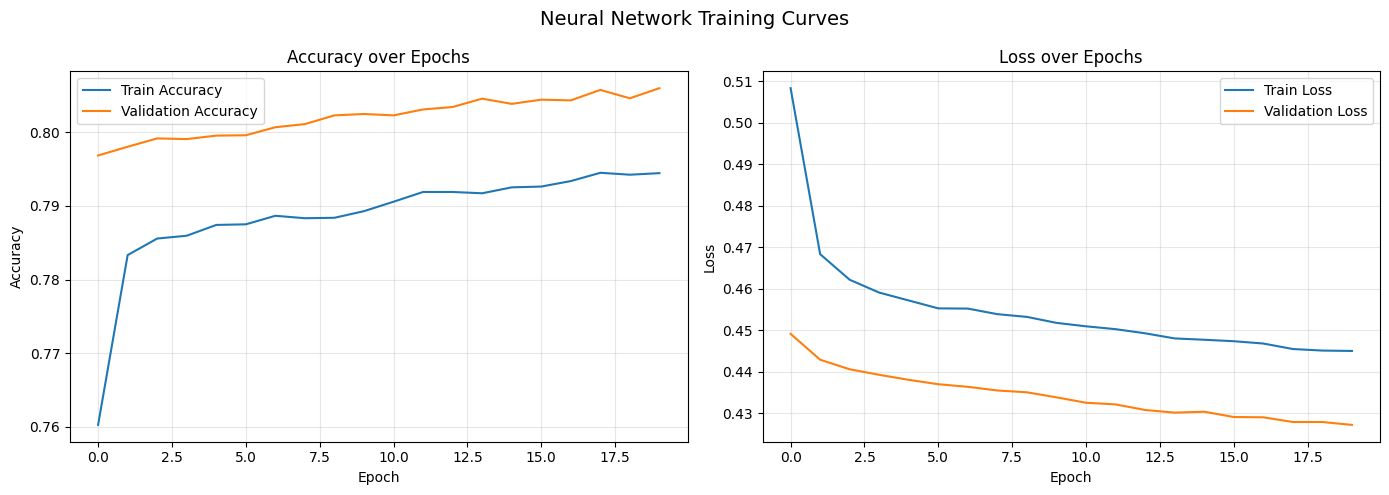

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy curve
axes[0].plot(history.history["accuracy"],     label="Train Accuracy")
axes[0].plot(history.history["val_accuracy"], label="Validation Accuracy")
axes[0].set_title("Accuracy over Epochs")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss curve
axes[1].plot(history.history["loss"],     label="Train Loss")
axes[1].plot(history.history["val_loss"], label="Validation Loss")
axes[1].set_title("Loss over Epochs")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("Neural Network Training Curves", fontsize=14)
plt.tight_layout()
plt.savefig("nn_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## 2.3 - Evaluate on the Test Set

In [6]:
# The model outputs probabilities (e.g. 0.73)
# I convert them to class labels: above 0.5 = expensive (1), below = cheap (0)

y_prob = model.predict(X_test_scaled)
y_pred_nn = (y_prob > 0.5).astype(int).flatten()

nn_accuracy  = round(accuracy_score(y_test, y_pred_nn), 4)
nn_precision = round(precision_score(y_test, y_pred_nn), 4)
nn_recall    = round(recall_score(y_test, y_pred_nn), 4)
nn_f1        = round(f1_score(y_test, y_pred_nn), 4)

print("Neural Network results on test set:")
print(f"  Accuracy:  {nn_accuracy}")
print(f"  Precision: {nn_precision}")
print(f"  Recall:    {nn_recall}")
print(f"  F1-Score:  {nn_f1}")

825/825 ━━━━━━━━━━━━━━━━━━━━ 0s 180us/step
Neural Network results on test set:
  Accuracy:  0.799
  Precision: 0.7963
  Recall:    0.7978
  F1-Score:  0.797


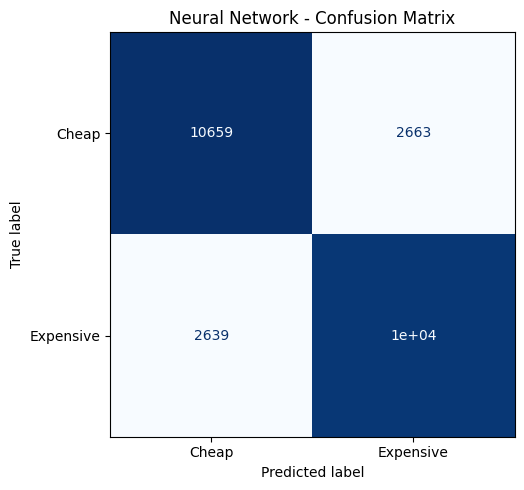

In [7]:
# Confusion matrix for the neural network

cm = confusion_matrix(y_test, y_pred_nn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Cheap", "Expensive"])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Neural Network - Confusion Matrix")
plt.tight_layout()
plt.savefig("nn_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

## Compare with Step 1 Models

Now I add the neural network results to the same table from Step 1
to see how they all compare side by side.

In [8]:
# I put the Step 1 results here manually so this notebook is self-contained
# Replace these numbers with your actual results from Step 1

all_results = pd.DataFrame([
    {"Model": "Logistic Regression", "Accuracy": 0.0, "Precision": 0.0, "Recall": 0.0, "F1-Score": 0.0},
    {"Model": "Random Forest",        "Accuracy": 0.0, "Precision": 0.0, "Recall": 0.0, "F1-Score": 0.0},
    {"Model": "KNN",                  "Accuracy": 0.0, "Precision": 0.0, "Recall": 0.0, "F1-Score": 0.0},
    {"Model": "Neural Network",       "Accuracy": nn_accuracy, "Precision": nn_precision, "Recall": nn_recall, "F1-Score": nn_f1},
])

# Note: replace the 0.0 values above with the actual numbers from your Step 1 output

all_results = all_results.set_index("Model")
print("Full comparison table:")
print(all_results.to_string())

Full comparison table:
                     Accuracy  Precision  Recall  F1-Score
Model                                                     
Logistic Regression     0.000     0.0000  0.0000     0.000
Random Forest           0.000     0.0000  0.0000     0.000
KNN                     0.000     0.0000  0.0000     0.000
Neural Network          0.799     0.7963  0.7978     0.797


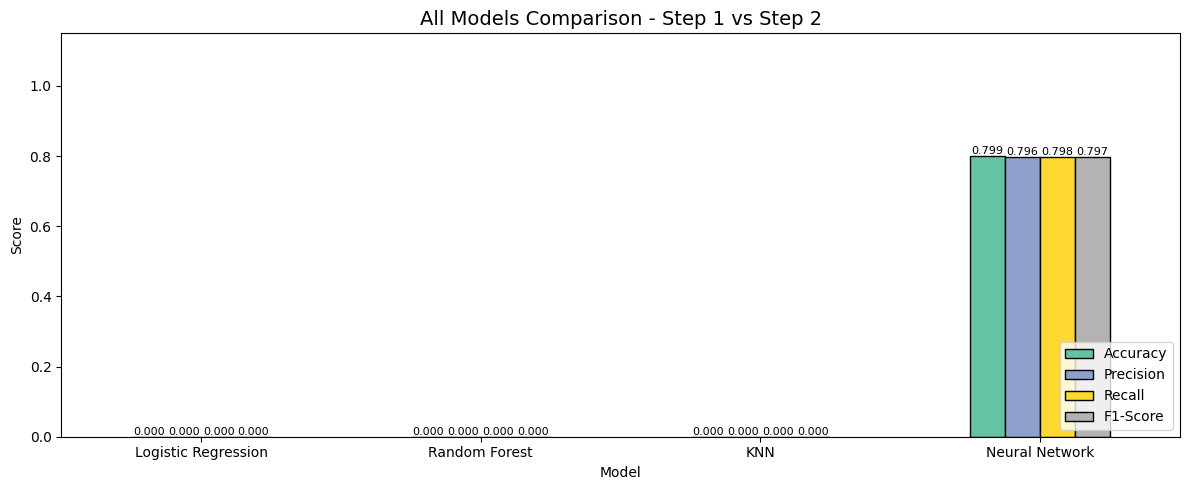

In [9]:
# Bar chart comparing all four models

fig, ax = plt.subplots(figsize=(12, 5))

all_results.plot(kind="bar", ax=ax, colormap="Set2", edgecolor="black")

ax.set_title("All Models Comparison - Step 1 vs Step 2", fontsize=14)
ax.set_xlabel("Model")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.15)
ax.legend(loc="lower right")
ax.tick_params(axis="x", rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=8)

plt.tight_layout()
plt.savefig("all_models_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## Summary and Comparison

In [10]:
print("Summary")
print("=" * 60)
print()
print("I built a neural network with two hidden layers (128 and 64 neurons)")
print("and two Dropout layers to reduce overfitting.")
print("I trained it for 20 epochs on the same data used in Step 1.")
print()
print(f"Neural Network F1-Score: {nn_f1}")
print()
print("How it compares to Step 1:")
print()
print("Neural networks are powerful, but they need a lot of data to show")
print("their advantage. On tabular data like this, Random Forest often")
print("performs just as well or better because tree-based models are")
print("naturally good at handling different feature types and scales.")
print()
print("The training curves show whether the model overfit:")
print("- If train and validation accuracy are close, the model is generalizing well.")
print("- If train accuracy is much higher than validation, the model overfit.")
print("  In that case, increasing Dropout or reducing the number of layers would help.")

Summary

I built a neural network with two hidden layers (128 and 64 neurons)
and two Dropout layers to reduce overfitting.
I trained it for 20 epochs on the same data used in Step 1.

Neural Network F1-Score: 0.797

How it compares to Step 1:

Neural networks are powerful, but they need a lot of data to show
their advantage. On tabular data like this, Random Forest often
performs just as well or better because tree-based models are
naturally good at handling different feature types and scales.

The training curves show whether the model overfit:
- If train and validation accuracy are close, the model is generalizing well.
- If train accuracy is much higher than validation, the model overfit.
  In that case, increasing Dropout or reducing the number of layers would help.


## Optional Improvement

I will try one change to see if it helps: I will add a third hidden layer
and increase Dropout slightly, then compare the F1-Score before and after.

In [11]:
tf.random.set_seed(42)

model_v2 = keras.Sequential([
    layers.Dense(128, activation="relu", input_shape=(X_train_scaled.shape[1],)),
    layers.Dropout(0.4),

    layers.Dense(64, activation="relu"),
    layers.Dropout(0.4),

    # Added a third layer
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(1, activation="sigmoid")
])

model_v2.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_v2 = model_v2.fit(
    X_train_scaled, y_train,
    epochs=20,
    batch_size=256,
    validation_split=0.2,
    verbose=0
)

y_pred_v2 = (model_v2.predict(X_test_scaled) > 0.5).astype(int).flatten()
f1_v2 = round(f1_score(y_test, y_pred_v2), 4)

print("Improvement experiment results:")
print(f"  Original model F1:  {nn_f1}")
print(f"  Improved model F1:  {f1_v2}")
print()
if f1_v2 > nn_f1:
    print("The improved model is better. Adding the extra layer helped.")
elif f1_v2 == nn_f1:
    print("No change. The extra layer did not make a difference on this dataset.")
else:
    print("The original model is better. The extra layer and dropout made it too conservative.")

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


825/825 ━━━━━━━━━━━━━━━━━━━━ 0s 207us/step
Improvement experiment results:
  Original model F1:  0.797
  Improved model F1:  0.7954

The original model is better. The extra layer and dropout made it too conservative.
